# Case Study 2 - Question 2

Q2: the client, the municipality and the engineering team care about different things.
Show how the preferred design changes depending on whose priorities you use, and discuss what
that means.

Same 10 feasible designs as Q1 - what changes here is the **weights**, not the designs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(0)

configs    = pd.read_csv("../data/configurations.csv")
thresholds = pd.read_csv("../data/thresholds.csv")
CRIT  = ["pv", "daylight", "compactness", "fsi"]
LABEL = {"pv":"PV", "daylight":"Daylight", "compactness":"Compactness", "fsi":"FSI"}
rows  = configs.set_index("id")
mins  = dict(zip(thresholds.criterion, thresholds.minimum))

# the 10 feasible designs from Q1
feasible = [x for x in rows.index if all(rows.loc[x, c] >= mins[c] for c in CRIT)]
print("feasible designs:", feasible)

feasible designs: ['C1', 'C6', 'C8', 'C11', 'C14', 'C15', 'C18', 'C21', 'C25', 'C28']


### Step 1 - turn each stakeholder into a weighting

Each stakeholder emphasised different criteria in the meeting. We turn that into weights (they add
up to 1). The client cared about density (FSI); the municipality about solar and daylight; the
engineering team about compactness.

In [2]:
profiles = {
    "Client":       {"pv":.10, "daylight":.10, "compactness":.10, "fsi":.70},
    "Municipality": {"pv":.35, "daylight":.35, "compactness":.15, "fsi":.15},
    "Engineering":  {"pv":.15, "daylight":.15, "compactness":.55, "fsi":.15},
}
pd.DataFrame(profiles).T[CRIT].rename(columns=LABEL)

,PV,Daylight,Compactness,FSI
Client,0.10,0.10,0.10,0.70
Municipality,0.35,0.35,0.15,0.15
Engineering,0.15,0.15,0.55,0.15


### Step 2 - who wins under each stakeholder?

For each stakeholder, score every feasible design (weight x value, added up) and take the highest.

In [3]:
def score(design, w):
    return sum(w[c] * rows.loc[design, c] for c in CRIT)

scores = pd.DataFrame({name: {d: score(d, w) for d in feasible}
                       for name, w in profiles.items()})

winners = scores.idxmax()
print("winner under each stakeholder:")
print(winners.to_string())

winner under each stakeholder:
Client           C8
Municipality     C1
Engineering     C14


Three stakeholders, three different winners. The design you recommend depends on whose priorities
you adopt.

### Visual 1 - the scores side by side

Each panel is one stakeholder. Bars are the 10 designs' scores; the winner is highlighted.

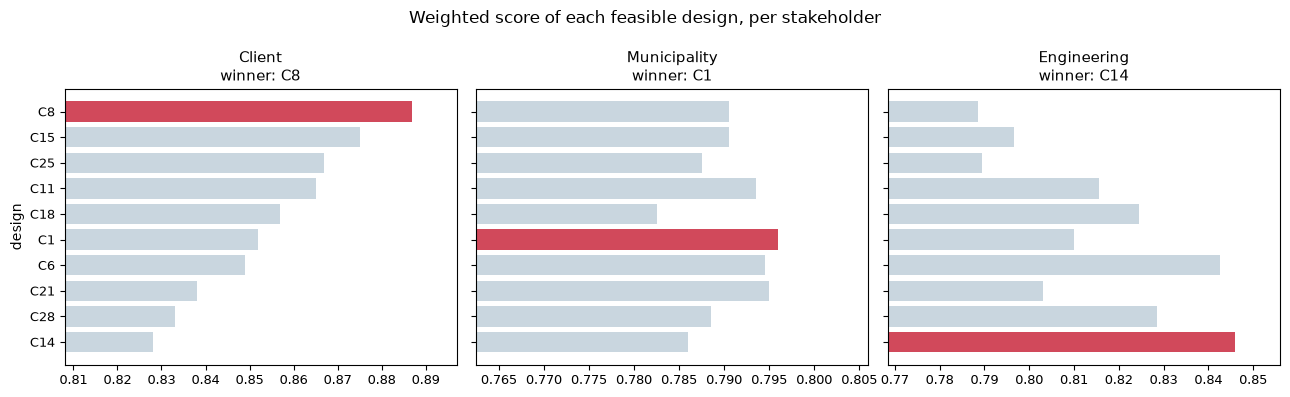

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, name in zip(axes, profiles):
    s = scores[name].sort_values()
    win = s.idxmax()
    colors = ['#d1495b' if d == win else '#c9d6df' for d in s.index]
    ax.barh(s.index, s.values, color=colors)
    ax.set_xlim(s.min() - 0.02, s.max() + 0.01)
    ax.set_title(f"{name}\nwinner: {win}", fontsize=11)
    ax.tick_params(labelsize=9)
axes[0].set_ylabel("design")
fig.suptitle("Weighted score of each feasible design, per stakeholder", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/q2_scores_per_stakeholder.png", dpi=120, bbox_inches="tight")
plt.show()

Notice two things: the winner (red) is different in each panel, but the bars are all bunched
together - the winner barely beats the runner-up. So a single "winner" is fragile.

### Step 3 - try every possible weighting (not just three)

The three profiles above are our guesses. To be fair, sample thousands of random weightings and
count how often each design comes first. This shows the whole picture, not three points.

In [5]:
Yf = rows.loc[feasible, CRIT].values
wins = {d: 0 for d in feasible}
N = 50000
for _ in range(N):
    w = np.random.dirichlet([1, 1, 1, 1])
    wins[feasible[np.argmax(Yf @ w)]] += 1
win_pct = pd.Series({d: wins[d] / N * 100 for d in feasible}).sort_values(ascending=False)
win_pct.round(1)

C8     38.3
C14    30.4
C6     20.1
C21     7.4
C1      2.9
C18     0.9
C11     0.0
C15     0.0
C25     0.0
C28     0.0
dtype: float64

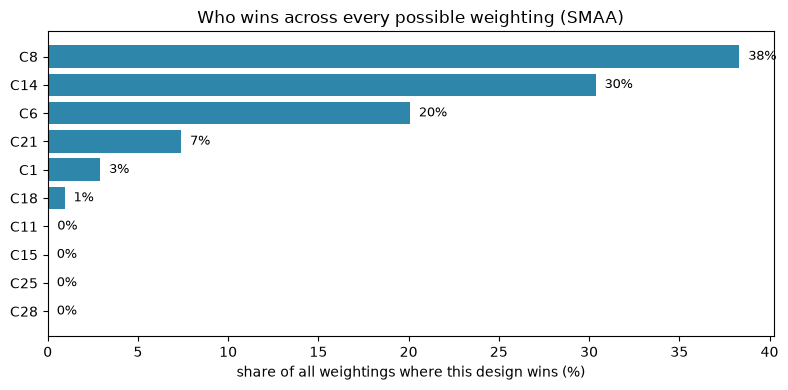

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2e86ab' if v > 0 else '#e8b4b8' for v in win_pct.values]
ax.barh(win_pct.index[::-1], win_pct.values[::-1], color=colors[::-1])
for i, (d, v) in enumerate(win_pct[::-1].items()):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9)
ax.set_xlabel("share of all weightings where this design wins (%)")
ax.set_title("Who wins across every possible weighting (SMAA)")
plt.tight_layout()
plt.savefig("../figures/q2_smaa_winshare.png", dpi=120, bbox_inches="tight")
plt.show()

**C6, C8 and C14 take almost all the wins between them.** Three designs win 0% - no weighting
ever picks them. So whichever stakeholder you are, the recommendation lands on one of these three.

### Step 4 - the hidden structure: three stakeholders, really two camps

From Q1 we know PV and FSI move together, and both move opposite to daylight. That means the client
(wants FSI) and the municipality (want PV) are actually pulling the **same** way - toward dense,
high-solar buildings. The real tension is **daylight vs the rest**.

Plot the feasible designs on daylight (up) vs FSI (right) to see it.

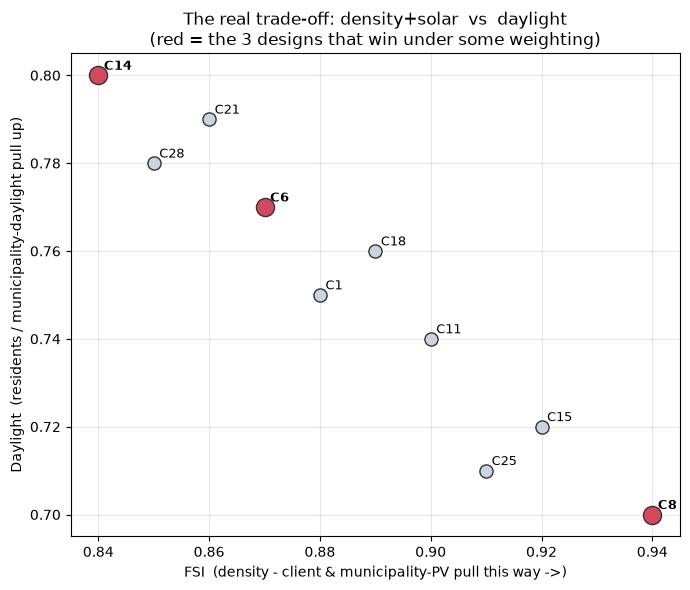

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
top3 = ["C6", "C8", "C14"]
for d in feasible:
    x, y = rows.loc[d, "fsi"], rows.loc[d, "daylight"]
    is_top = d in top3
    ax.scatter(x, y, s=170 if is_top else 90,
               color='#d1495b' if is_top else '#c9d6df',
               edgecolor='#333', zorder=3)
    ax.annotate(d, (x, y), fontsize=9, fontweight='bold' if is_top else 'normal',
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("FSI  (density - client & municipality-PV pull this way ->)")
ax.set_ylabel("Daylight  (residents / municipality-daylight pull up)")
ax.set_title("The real trade-off: density+solar  vs  daylight\n(red = the 3 designs that win under some weighting)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/q2_tradeoff.png", dpi=120, bbox_inches="tight")
plt.show()

The designs fall on a downward slope: more FSI means less daylight. C8 sits bottom-right (density
camp), C14 top-left (daylight camp), C6 in the middle (compromise). That single line is the whole
disagreement.

### Q2 answer

- Different stakeholders prefer different designs: **Client -> C8, Municipality -> C1, Engineering
  -> C14** (and across all weightings only C6, C8, C14 ever win).
- But the winning margins are tiny, and we invented the weights - the case gives none. So the honest
  statement is *"if a stakeholder weights the criteria this way, this design wins,"* not *"this is
  the stakeholder's design."*
- Structurally the three stakeholders are really **two camps**: density + solar (client + municipality)
  vs daylight (residents). The genuine decision is how much daylight to trade for density.

So Q2's message: the choice is a **value judgement between two camps**, not a calculation. Narrowing
to C6 / C8 / C14 is as far as the data takes us; picking one is Studio Delta's call.